![alt text](kayfaio_logo2-1.jpg)
# **Kayfa Academy Internship**
# Task 1: HR Attrition Dataset Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Data loading

In [3]:
train_df = pd.read_csv("dataset/train.csv")
train_df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [4]:
test_df = pd.read_csv("dataset/test.csv")
test_df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


In [5]:
df = pd.concat([train_df, test_df], ignore_index=True)
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [6]:
print("Train Length:", len(train_df), '\nTest Length:', len(test_df), '\n\nTotal Length:',len(df))

Train Length: 59598 
Test Length: 14900 

Total Length: 74498


In [7]:
del train_df, test_df

In [8]:
df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure',
       'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities',
       'Company Reputation', 'Employee Recognition', 'Attrition'],
      dtype='str')

#### Change column names into snake case

In [9]:
df.columns = df.columns.str.lower().str.replace(' ','_')
print("New column names:",df.columns, sep='\n\n')

New column names:

Index(['employee_id', 'age', 'gender', 'years_at_company', 'job_role',
       'monthly_income', 'work-life_balance', 'job_satisfaction',
       'performance_rating', 'number_of_promotions', 'overtime',
       'distance_from_home', 'education_level', 'marital_status',
       'number_of_dependents', 'job_level', 'company_size', 'company_tenure',
       'remote_work', 'leadership_opportunities', 'innovation_opportunities',
       'company_reputation', 'employee_recognition', 'attrition'],
      dtype='str')


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74498 entries, 0 to 74497
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   employee_id               74498 non-null  int64
 1   age                       74498 non-null  int64
 2   gender                    74498 non-null  str  
 3   years_at_company          74498 non-null  int64
 4   job_role                  74498 non-null  str  
 5   monthly_income            74498 non-null  int64
 6   work-life_balance         74498 non-null  str  
 7   job_satisfaction          74498 non-null  str  
 8   performance_rating        74498 non-null  str  
 9   number_of_promotions      74498 non-null  int64
 10  overtime                  74498 non-null  str  
 11  distance_from_home        74498 non-null  int64
 12  education_level           74498 non-null  str  
 13  marital_status            74498 non-null  str  
 14  number_of_dependents      74498 non-null  int64
 

In [11]:
df.describe()

,employee_id,age,years_at_company,monthly_income,number_of_promotions,distance_from_home,number_of_dependents,company_tenure
count,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000
mean,37249.500000,38.529746,15.721603,7299.379514,0.832935,49.991584,1.650326,55.727456
std,21505.864514,12.083456,11.223744,2152.508566,0.995289,28.513611,1.553633,25.399349
min,1.000000,18.000000,1.000000,1226.000000,0.000000,1.000000,0.000000,2.000000
25%,18625.250000,28.000000,7.000000,5652.000000,0.000000,25.000000,0.000000,36.000000
50%,37249.500000,39.000000,13.000000,7348.000000,1.000000,50.000000,1.000000,56.000000
75%,55873.750000,49.000000,23.000000,8876.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [12]:
df.isnull().sum()

employee_id                 0
age                         0
gender                      0
years_at_company            0
job_role                    0
monthly_income              0
work-life_balance           0
job_satisfaction            0
performance_rating          0
number_of_promotions        0
overtime                    0
distance_from_home          0
education_level             0
marital_status              0
number_of_dependents        0
job_level                   0
company_size                0
company_tenure              0
remote_work                 0
leadership_opportunities    0
innovation_opportunities    0
company_reputation          0
employee_recognition        0
attrition                   0
dtype: int64

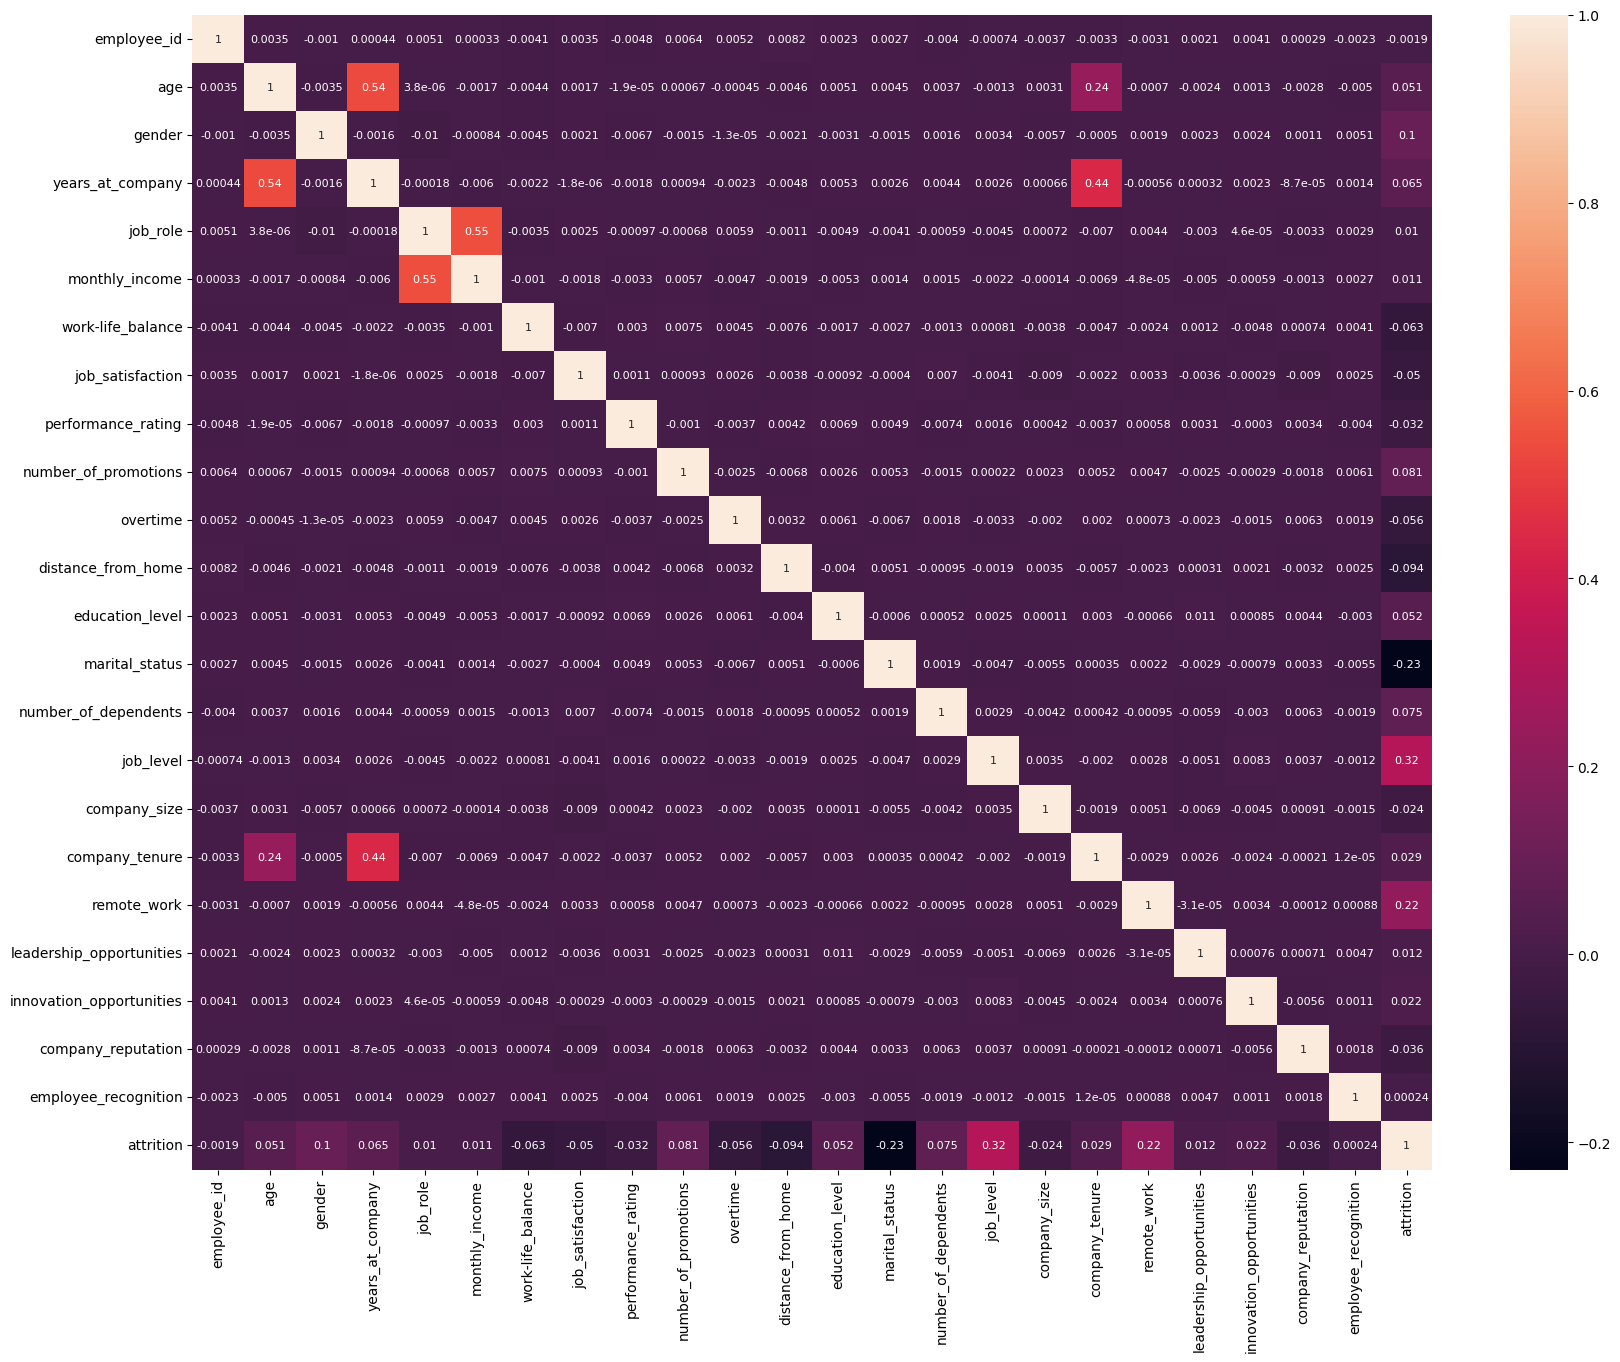

In [13]:
df2 = df.copy()
for c in df2.columns:
    if df2[c].dtype.type == str:
        df2[c] = df2[c].astype('category').cat.codes

plt.figure(figsize=(20,15))
sns.heatmap(df2.corr(), annot=True, annot_kws={'size': 8})
plt.show()
del df2

In [14]:
df.head(2)

,employee_id,age,gender,years_at_company,job_role,monthly_income,work-life_balance,job_satisfaction,performance_rating,number_of_promotions,...,number_of_dependents,job_level,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed


In [15]:
df.to_csv('data.csv', index=False)

## Data Analysis

In [16]:
df['age'].mean()

np.float64(38.52974576498698)

In [17]:
df.groupby('attrition')['monthly_income'].mean()

attrition
Left      7275.183913
Stayed    7321.251278
Name: monthly_income, dtype: float64

#### Check the outliers

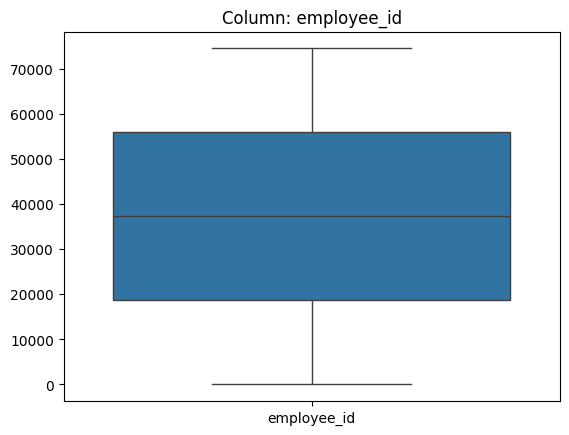

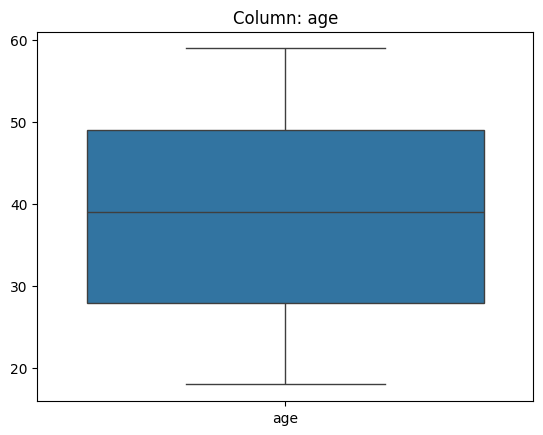

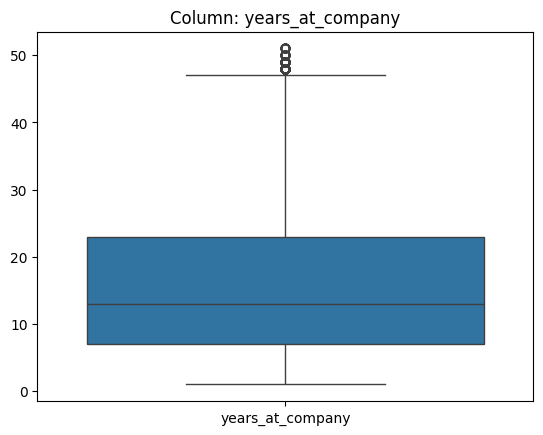

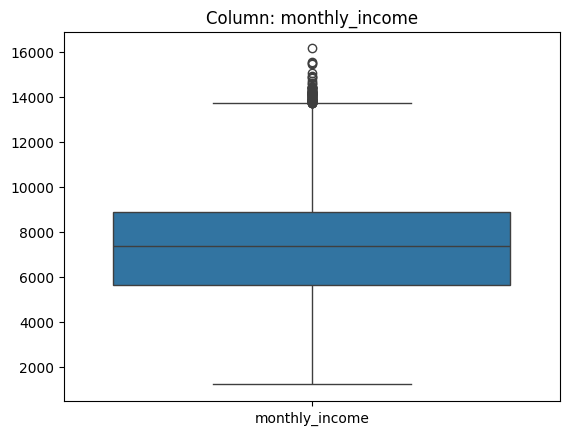

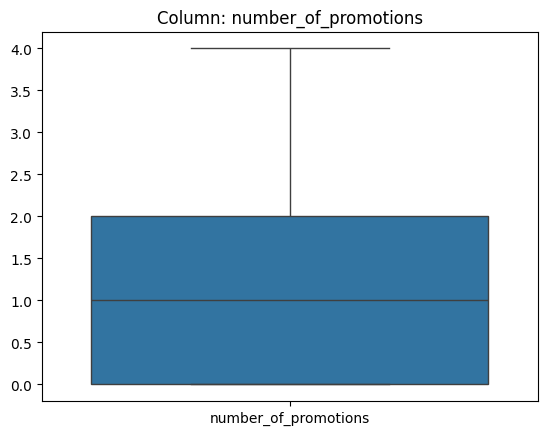

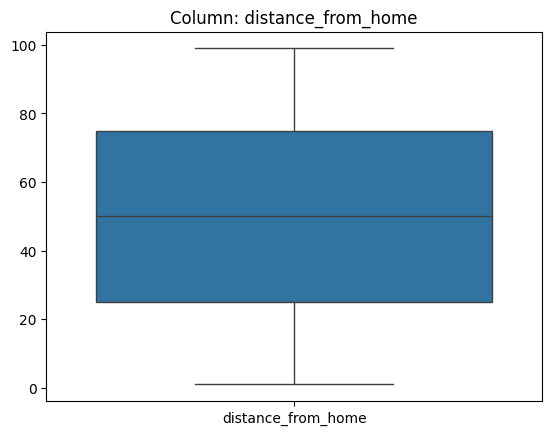

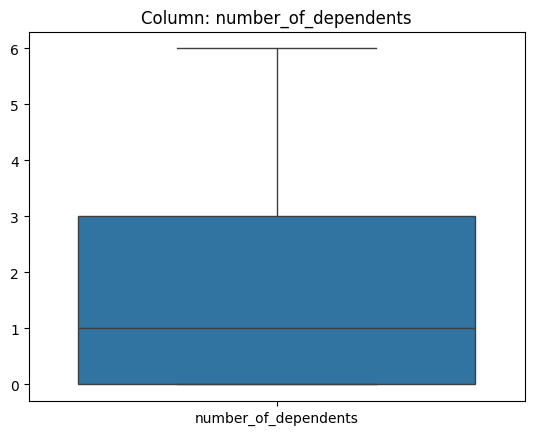

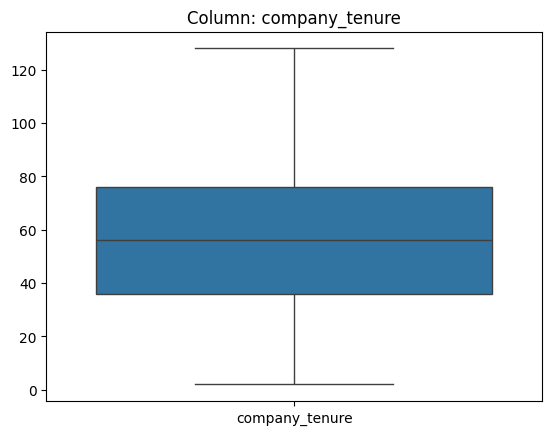

In [18]:
for c in df.columns:
    if df[c].dtype != 'str':
        sns.boxplot([df[c]], )
        plt.title(f"Column: {c}")
        plt.show()

In [19]:
q1 = df['monthly_income'].quantile(0.25)
q3 = df['monthly_income'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1-1.5*iqr
upper_bound = q3+1.5*iqr

In [20]:
print("Lower bound:",lower_bound, '\nUpper bound:',upper_bound)

Lower bound: 816.0 
Upper bound: 13712.0


In [21]:
df2 = df[df['monthly_income'] <= upper_bound]

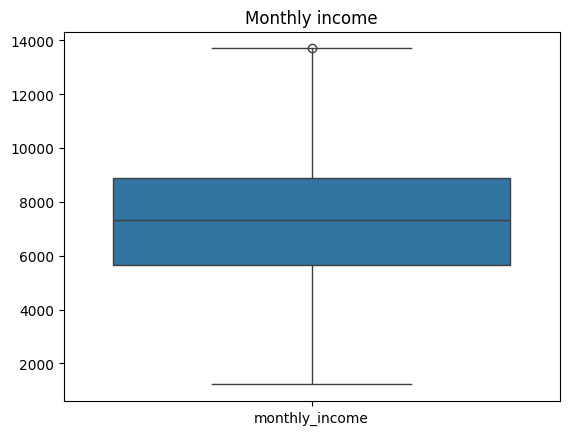

In [22]:
sns.boxplot([df2['monthly_income']])
plt.title("Monthly income")
plt.show()

---

#### what is the average monthly salaries ratio for left and stayed employees?

In [23]:
df2.groupby('attrition')['monthly_income'].mean()

attrition
Left      7268.651612
Stayed    7315.637457
Name: monthly_income, dtype: float64

#### what is the number of dependents ratio for left and stayed employees

In [26]:
del df2

In [24]:
df.groupby('attrition')['number_of_dependents'].mean()

attrition
Left      1.528414
Stayed    1.760530
Name: number_of_dependents, dtype: float64

#### what is the employee recognition chance ratio for left only employees

In [25]:
df[df['attrition']=='Left'].groupby('employee_recognition')['attrition'].count().sort_values(ascending=False)

employee_recognition
Low          14163
Medium       10784
High          8734
Very High     1689
Name: attrition, dtype: int64

---

#### what is the working years at company for attrition employtees

Text(0, 0.5, 'Number of attrition employees')

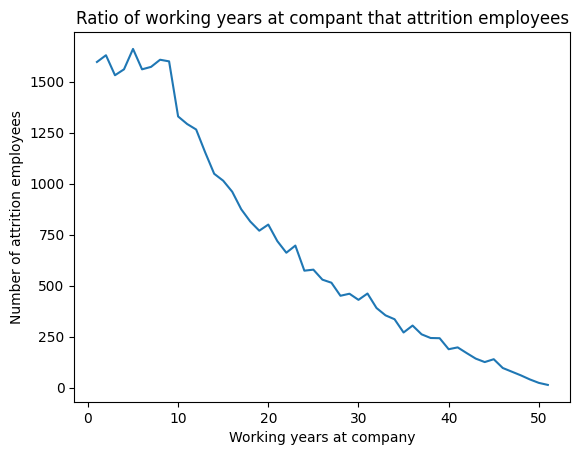

In [27]:
plt.Figure()
plt.plot(df[df['attrition']=='Left'].groupby('years_at_company')['attrition'].count().index, 
        df[df['attrition']=='Left'].groupby('years_at_company')['attrition'].count().values)

plt.title("Ratio of working years at compant that attrition employees")
plt.xlabel("Working years at company")
plt.ylabel("Number of attrition employees")

---

In [28]:
df.head()

,employee_id,age,gender,years_at_company,job_role,monthly_income,work-life_balance,job_satisfaction,performance_rating,number_of_promotions,...,number_of_dependents,job_level,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [29]:
df.columns

Index(['employee_id', 'age', 'gender', 'years_at_company', 'job_role',
       'monthly_income', 'work-life_balance', 'job_satisfaction',
       'performance_rating', 'number_of_promotions', 'overtime',
       'distance_from_home', 'education_level', 'marital_status',
       'number_of_dependents', 'job_level', 'company_size', 'company_tenure',
       'remote_work', 'leadership_opportunities', 'innovation_opportunities',
       'company_reputation', 'employee_recognition', 'attrition'],
      dtype='str')

In [30]:
# is the reason in مادي ولا معنوي

d = df.groupby('attrition')['monthly_income'].mean().reset_index(name='average_income')
d

fig = px.pie(d,
             names='attrition',
             values='average_income',
             title='Salaries Ration beteen stayed and left emplyees',
             hole=0.3,
             )

fig.update_traces(textinfo='percent+value')
fig.show()

In [31]:
d = df.groupby('attrition')['number_of_dependents'].mean().reset_index(name='number_of_dependents')
d

fig = px.pie(d,
             names='attrition',
             values='number_of_dependents',
             title='Average Number of Dependents Ration beteen stayed and left emplyees',
             hole=0.3,
             )

fig.update_traces(textinfo='percent+value')
fig.show()

In [32]:
df[df['attrition']=='Left'].groupby('job_role')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

,job_role,attrition_number
0,Technology,9099
1,Healthcare,8112
2,Education,7636
3,Media,5620
4,Finance,4903


In [33]:
d = df[df['attrition']=='Left'].groupby('job_role')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

fig = px.bar(
    d, 
    x='job_role',
    y='attrition_number',
    title='Ratio of job domain and attrition number',
    labels={'job_role': 'Job Role', 'attrition_number': 'Number of Attritions'},
    text_auto='.1f',
    color='job_role'
)

fig.show()


In [ ]:
d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('job_role')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )
d['attrition_rate'] = d['attrition_rate']*100

fig = px.bar(
    d, 
    x='job_role',
    y='attrition_rate',
    title='Ratio of job domain and attrition number',
    labels={'job_role': 'Job Role', 'attrition_number': 'Number of Attritions'},
    text_auto='.1f',
    color='job_role'
)

fig.show()


In [36]:
d = df[df['attrition']=='Left'].groupby('employee_recognition')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

fig = px.bar(
    d, 
    x='employee_recognition',
    y='attrition_number',
    title='Ratio of employee recognition and attrition number',
    text_auto='.1f',
    color='employee_recognition'
)

fig.show()


In [37]:
d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('company_size')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )
d['attrition_rate'] = d['attrition_rate']*100

d = d.sort_values(by='company_size', key=lambda x:x.map({'Small':1,'Medium':2,'Large':3}))

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='company_size',
    y='attrition_rate',
    title='Attrition rate according to company reputation',
    # text_auto='0.1f',
    text='Percent',
    color='company_size',
    width=1000
)


fig.show()

In [38]:
d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('company_reputation')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )
d['attrition_rate'] = d['attrition_rate']*100

d = d.sort_values(by='company_reputation', key=lambda x:x.map({'Poor':1,'Fair':2,'Good':3,'Excellent':4}))

d['Percent'] = d.apply(lambda x: f"{x['attrition_rate']} %", axis=1)
d

,company_reputation,attrition_rate,Percent
3,Poor,56.020111,56.020111140513364 %
1,Fair,51.771946,51.77194643581766 %
2,Good,42.999301,42.999300736915714 %
0,Excellent,43.957378,43.957377933639066 %


In [39]:
d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('company_reputation')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )
d['attrition_rate'] = d['attrition_rate']*100

d = d.sort_values(by='company_reputation', key=lambda x:x.map({'Poor':1,'Fair':2,'Good':3,'Excellent':4}))

# d['percent'] = str(d['attrition_rate']) + ' %'

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='company_reputation',
    y='attrition_rate',
    title='Attrition rate according to company reputation',
    # text_auto='0.1f',
    text='Percent',
    color='company_reputation',
    width=1000
)


fig.show()

In [40]:
d = df[df['attrition']=='Left'].groupby('number_of_promotions')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

total = d['attrition_number'].sum()
d['Percent'] = (d['attrition_number'] / total) * 100

d['Percent'] = d.apply(lambda row: f"{row['attrition_number']}   ({row['Percent']:.1f}%)", axis=1)
d


,number_of_promotions,attrition_number,Percent
0,0,18304,18304.0 (51.8%)
1,1,9147,9147.0 (25.9%)
2,2,6679,6679.0 (18.9%)
3,3,1010,1010.0 (2.9%)
4,4,230,230.0 (0.7%)


In [ ]:
# d = df[df['attrition']=='Left'].groupby('number_of_promotions')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('number_of_promotions')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
    )

d['attrition_rate'] = d['attrition_rate'] * 100

fig = px.bar(
    d, 
    x='number_of_promotions',
    y='attrition_rate',
    title='Ratio of number of promotions and attrition percentage in each',
    color='number_of_promotions',
    text_auto='0.1f',
    labels={'number_of_promotions':'Number of Promotions', 'attrition_rate':'Attrition Rate'}
)

fig.show()


In [42]:
df.groupby('number_of_promotions')['years_at_company'].mean().reset_index(name="Average Years at Company")

,number_of_promotions,Average Years at Company
0,0,15.724431
1,1,15.716985
2,2,15.670016
3,3,15.836256
4,4,15.944388


In [43]:
d = df.groupby('number_of_promotions')['years_at_company'].mean().reset_index(name="experience")

fig = px.bar(
    d, 
    x='number_of_promotions',
    y='experience',
    title='Ratio of number of promotions and average years at company for each',
    color='number_of_promotions',
    text_auto='0.1f',
    labels={'number_of_promotions':'Number of Promotions', 'experience':'Average Years at Company'}
)

fig.show()


### According to Employee

In [44]:
df.head()

,employee_id,age,gender,years_at_company,job_role,monthly_income,work-life_balance,job_satisfaction,performance_rating,number_of_promotions,...,number_of_dependents,job_level,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [45]:
d = df.groupby('attrition')['distance_from_home'].mean().sort_values(ascending=False).reset_index(name='distance_from_home')

fig = px.bar(
    d, 
    x='attrition',
    y='distance_from_home',
    text_auto='0.1f',
    title='Average distance from home for stayed and left employees',
    color='distance_from_home',
)

fig.show()


---

---
---
---

In [46]:
df.columns

Index(['employee_id', 'age', 'gender', 'years_at_company', 'job_role',
       'monthly_income', 'work-life_balance', 'job_satisfaction',
       'performance_rating', 'number_of_promotions', 'overtime',
       'distance_from_home', 'education_level', 'marital_status',
       'number_of_dependents', 'job_level', 'company_size', 'company_tenure',
       'remote_work', 'leadership_opportunities', 'innovation_opportunities',
       'company_reputation', 'employee_recognition', 'attrition'],
      dtype='str')

In [47]:
df.head()

,employee_id,age,gender,years_at_company,job_role,monthly_income,work-life_balance,job_satisfaction,performance_rating,number_of_promotions,...,number_of_dependents,job_level,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [48]:
df.groupby('overtime')['attrition'].count().reset_index(name='attrition rate')

,overtime,attrition rate
0,No,50157
1,Yes,24341


In [49]:
# d = df[df['attrition']=='Left'].groupby('overtime')['attrition'].count().reset_index(name='attrition rate')

d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('overtime')['is_left']
     .mean()
     .reset_index(name='attrition rate')
     )
d['attrition rate'] = d['attrition rate'] * 100

fig = px.pie(d,
             names='overtime',
             values='attrition rate',
             title='Overtime Ratio and left emplyees',
             hole=0.3,
             color='attrition rate'
             )

fig.update_traces(textinfo='percent+value')
fig.show()

In [50]:
d = df[df['attrition']=='Left'].groupby('remote_work')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')
d

,remote_work,attrition_number
0,No,31861
1,Yes,3509


In [51]:
d['remote_work'] = d['remote_work'].map(lambda x: 'Remote' if x=='Yes' else 'Onsite')
d

,remote_work,attrition_number
0,Onsite,31861
1,Remote,3509


In [52]:
# d = df[df['attrition']=='Left'].groupby('remote_work')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('remote_work')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )
d['remote_work'] = d['remote_work'].map(lambda x: 'Remote' if x=='Yes' else 'Onsite')
d['attrition_rate'] = d['attrition_rate']*100

d = d.sort_values(by='remote_work', key=lambda x:x.map({'Poor':1,'Fair':2,'Good':3,'Excellent':4}))

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='remote_work',
    y='attrition_rate',
    title='Attrition rate according to company reputation',
    # text_auto='0.1f',
    text='Percent',
    color='remote_work',
    width=1000
)

fig.show()



In [53]:
df.head()

,employee_id,age,gender,years_at_company,job_role,monthly_income,work-life_balance,job_satisfaction,performance_rating,number_of_promotions,...,number_of_dependents,job_level,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [54]:
d = df[['monthly_income', 'job_level', 'attrition']].groupby(['job_level','attrition'])['monthly_income'].mean().reset_index(name='average salary')
d

,job_level,attrition,average salary
0,Entry,Left,7290.685135
1,Entry,Stayed,7353.175277
2,Mid,Left,7259.922769
3,Mid,Stayed,7296.275202
4,Senior,Left,7246.842520
5,Senior,Stayed,7325.873916


In [55]:
d = df[['monthly_income', 'job_level', 'attrition']].groupby(['job_level','attrition'])['monthly_income'].mean().reset_index(name='average salary')

fig = px.bar(
    d,
    x='job_level',
    y='average salary',
    title='Salaries rate for each job level and attrition rate',
    text_auto='0.1f',
    barmode='group',
    color='attrition'
)

fig.show()



In [56]:
d = df[df['attrition']=='Left'].groupby('age')['attrition'].count().reset_index(name='attrition')

d = (d.map(lambda x: '18 - 29' if x>=18 and x<=29 else x)
  .map(lambda x: '30 - 39' if type(x)==int and x>=30 and x<=39 else x)
  .map(lambda x: '40 - 49' if type(x)==int and x>=40 and x<=49 else x)
  .map(lambda x: '50 - 59' if type(x)==int and x>=50 and x<=59 else x))

d = d.groupby('age')['attrition'].sum().reset_index(name='attrition')

fig = px.bar(
    d,
    x='age',
    y='attrition',
    title='Age ranges and number of attrition',
    text_auto='0.1f',
    color='age'
)

fig.show()


In [ ]:
# d = df[df['attrition']=='Left'].groupby('remote_work')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('marital_status')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )

d['attrition_rate'] = d['attrition_rate']*100

d = d.sort_values(by='marital_status', key=lambda x:x.map({'Single':1,'Married':2,'Divorced':3}))

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='marital_status',
    y='attrition_rate',
    title='Attrition rate according to company reputation',
    text='Percent',
    color='marital_status',
    width=1000
)

fig.show()


In [58]:
# df[df['attrition']=='Left'].groupby('innovation_opportunities')['attrition'].count()

d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('innovation_opportunities')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )

d['attrition_rate'] = d['attrition_rate']*100

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='innovation_opportunities',
    y='attrition_rate',
    title='Ration of innovation opportunity for attrition',
    text='Percent',
    color='innovation_opportunities',
    width=1000
)

fig.show()


In [59]:
# df[df['attrition']=='Left'].groupby('leadership_opportunities')['attrition'].count()

d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('leadership_opportunities')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )

d['attrition_rate'] = d['attrition_rate']*100

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='leadership_opportunities',
    y='attrition_rate',
    title='Ration of innovation opportunity for attrition',
    text='Percent',
    color='leadership_opportunities',
    width=1000
)

fig.show()


In [60]:
df.columns

Index(['employee_id', 'age', 'gender', 'years_at_company', 'job_role',
       'monthly_income', 'work-life_balance', 'job_satisfaction',
       'performance_rating', 'number_of_promotions', 'overtime',
       'distance_from_home', 'education_level', 'marital_status',
       'number_of_dependents', 'job_level', 'company_size', 'company_tenure',
       'remote_work', 'leadership_opportunities', 'innovation_opportunities',
       'company_reputation', 'employee_recognition', 'attrition'],
      dtype='str')

In [61]:
df.groupby('overtime')['attrition'].count().reset_index(name='attrition_rate')

,overtime,attrition_rate
0,No,50157
1,Yes,24341


In [62]:
d = (df.assign(work_overtime=(df['attrition']=='Left').astype(int))
     .groupby('overtime')['work_overtime']
     .mean()
     .reset_index(name='attrition_rate'))

d['attrition_rate'] = round(d['attrition_rate'] * 100, 2)

# d
d['overtime'] = d['overtime'].str.replace('No','No overtime').replace('Yes', 'Overtime work')

d

,overtime,attrition_rate
0,No overtime,45.53
1,Overtime work,51.49


In [63]:
d = (df.assign(work_overtime=(df['attrition']=='Left').astype(int))
     .groupby('overtime')['work_overtime']
     .mean()
     .reset_index(name='attrition_rate'))

d['attrition_rate'] = round(d['attrition_rate'] * 100, 2)

d['overtime'] = d['overtime'].str.replace('No','No overtime').replace('Yes', 'Overtime work')


d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)


fig = px.bar(
    d,
    x='overtime',
    y='attrition_rate',
    title='Ration of Overtime work for attrition',
    text='Percent',
    color='overtime',
    labels={'overtime':'Overtime', 'attrition_rate':'Attrition Rate %'}
)


fig.show()


In [64]:
d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('job_satisfaction')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )

d = d.sort_values(by='job_satisfaction', key=lambda x:x.map({'Low':1,'Medium':2,'High':3,'Very High':4}))

d['attrition_rate'] = d['attrition_rate']*100

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='job_satisfaction',
    y='attrition_rate',
    title='Attrition rate according to Job Satisfaction',
    text='Percent',
    color='job_satisfaction',
    labels={'job_satisfaction':'Job Satisfaction', 'attrition_rate':'Attrition Rate %'}
)

fig.show()



In [65]:
d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('performance_rating')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )

d = d.sort_values(by='performance_rating', key=lambda x:x.map({'Low':1,'Below Average':2,'Average':3,'High':4}))

d['attrition_rate'] = d['attrition_rate']*100

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='performance_rating',
    y='attrition_rate',
    title='Attrition rate according to Job Satisfaction',
    text='Percent',
    color='performance_rating',
    labels={'performance_rating':'Performance Rating', 'attrition_rate':'Attrition Rate %'}
)

fig.show()



---

In [66]:
df.describe()

,employee_id,age,years_at_company,monthly_income,number_of_promotions,distance_from_home,number_of_dependents,company_tenure
count,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000
mean,37249.500000,38.529746,15.721603,7299.379514,0.832935,49.991584,1.650326,55.727456
std,21505.864514,12.083456,11.223744,2152.508566,0.995289,28.513611,1.553633,25.399349
min,1.000000,18.000000,1.000000,1226.000000,0.000000,1.000000,0.000000,2.000000
25%,18625.250000,28.000000,7.000000,5652.000000,0.000000,25.000000,0.000000,36.000000
50%,37249.500000,39.000000,13.000000,7348.000000,1.000000,50.000000,1.000000,56.000000
75%,55873.750000,49.000000,23.000000,8876.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [67]:
q0 = df['monthly_income'].min()
q1 = df['monthly_income'].quantile(0.25)
q2 = df['monthly_income'].quantile(0.5)
q3 = df['monthly_income'].quantile(0.75)
q4 = df['monthly_income'].max()

In [68]:
df['monthly_income'].values[0]

np.int64(5390)

In [69]:
q0 = df['monthly_income'].min()
q1 = df['monthly_income'].quantile(0.25)
q2 = df['monthly_income'].quantile(0.5)
q3 = df['monthly_income'].quantile(0.75)
q4 = df['monthly_income'].max()

d = df[df['attrition']=='Left'].groupby('monthly_income')['attrition'].count().reset_index(name='attrition')

d = (d.map(lambda x: f"{q0} - {q1}" if type(x)==int and (x>=q0 and x<=q1) else x)
  .map(lambda x: f"{q1} - {q2}" if type(x)==int and (x>q1 and x<=q2) else x)
  .map(lambda x: f"{q2} - {q3}" if type(x)==int and (x>q2 and x<=q3) else x)
  .map(lambda x: f"{q3} - {q4}" if type(x)==int and (x>q3 and x<=q4) else x)
  )

d = d.groupby('monthly_income')['attrition'].sum().reset_index(name='attrition')

fig = px.bar(
    d,
    x='monthly_income',
    y='attrition',
    title='Salaries ranges and number of attrition',
    text_auto='0.1f',
    labels={'monthly_income':'Salaries Range', 'attrition':'Attrition Number'},
    color='monthly_income',
    width=750
)

fig.show()


In [70]:
d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('job_level')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )

d['attrition_rate'] = d['attrition_rate']*100

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='job_level',
    y='attrition_rate',
    title='Relation of job level and attrition',
    text='Percent',
    color='job_level',
    labels={'job_level':'Job Level', 'attrition_rate':'Attrition Rate %'},
    width=1000
)

fig.show()


In [71]:
# df['number_of_dependents'].unique()

d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('number_of_dependents')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )

d['attrition_rate'] = d['attrition_rate']*100

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='number_of_dependents',
    y='attrition_rate',
    title='Relation of job level and attrition',
    text='Percent',
    color='number_of_dependents',
    labels={'number_of_dependents':'Number of Dependents', 'attrition_rate':'Attrition Rate %'},
    width=1000
)

fig.show()


In [72]:
df.columns

Index(['employee_id', 'age', 'gender', 'years_at_company', 'job_role',
       'monthly_income', 'work-life_balance', 'job_satisfaction',
       'performance_rating', 'number_of_promotions', 'overtime',
       'distance_from_home', 'education_level', 'marital_status',
       'number_of_dependents', 'job_level', 'company_size', 'company_tenure',
       'remote_work', 'leadership_opportunities', 'innovation_opportunities',
       'company_reputation', 'employee_recognition', 'attrition'],
      dtype='str')

In [73]:
d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('work-life_balance')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )

d = d.sort_values(by='work-life_balance', key=lambda x:x.map({'Poor':1,'Fair':2,'Good':3,'Excellent':4}))

d['attrition_rate'] = d['attrition_rate']*100

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='work-life_balance',
    y='attrition_rate',
    title='Relation of Work Life Balance and Attrition Rate',
    text='Percent',
    color='work-life_balance',
    labels={'work-life_balance':'Work Life Balance', 'attrition_rate':'Attrition Rate %'},
    width=1000
)

fig.show()


---

In [77]:
total_attrition_rate = round((df[df['attrition']=='Left'].value_counts().count() / df.value_counts().count()) * 100)
total_attrition_rate

47

In [75]:
d = df[
    (df['remote_work']=='No') & 
    (df['employee_recognition']=='Low') & 
    (df['marital_status']!='Married')&
    (df['job_level']=='Entry')
]

risk_employee = round((d[d['attrition']=='Left'].value_counts().count() / d.value_counts().count()) * 100)
risk_employee

81